# TrafficIQ Chat — Vehicle Counting, Speed Estimation & Conversational Traffic Analytics
**YOLOv8 (detection) + DeepSORT (tracking) + OpenCV (video I/O) + Groq-powered chatbot**

This notebook walks through the full pipeline step by step: detect vehicles, track them across frames, count line-crossings (separately by direction), estimate speed, save an annotated output video, and ask natural-language questions about the results.

Works in Google Colab or locally. If running locally, run this from the project root so the `modules/` folder is importable.

## 1. Install dependencies
(Skip this cell if you already ran `pip install -r requirements.txt` locally.)

In [1]:
%pip install ultralytics deep-sort-realtime opencv-python-headless pandas matplotlib groq python-dotenv -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Point to your input video
**Important:** put your video file inside the `sample_data/` folder, then set the filename below to match exactly.

If on Colab, uncomment the upload block instead.

In [2]:
import os

# --- Colab only: uncomment to upload a file instead ---
# from google.colab import files
# uploaded = files.upload()
# INPUT_VIDEO = list(uploaded.keys())[0]

# --- Local: put your video in sample_data/ and set its filename here ---
INPUT_VIDEO = "sample_data/traffic_sample.mp4"  # <-- change this to your actual filename
OUTPUT_VIDEO = "output_annotated.mp4"

print("Input:", INPUT_VIDEO)
print("File exists?", os.path.exists(INPUT_VIDEO))
if not os.path.exists(INPUT_VIDEO):
    print("\n⚠️  File not found. Files currently in sample_data/:", os.listdir("sample_data") if os.path.exists("sample_data") else "(sample_data folder not found)")

Input: sample_data/traffic_sample.mp4
File exists? True


## 3. Imports
Uses the same `modules/` package as `app.py` and `process_video.py`, so all three (Streamlit app, CLI script, notebook) share one codebase.

In [3]:
import cv2
import pandas as pd
import matplotlib.pyplot as plt

from modules.detector import VehicleDetector
from modules.tracker import VehicleTracker
from modules.speed_estimator import SpeedEstimator
from modules.utils import LineCounter, draw_annotations, build_vehicle_summary

## 4. Calibrate speed estimation
Measure a known real-world distance (e.g. lane width ≈ 3.65m on most highways/motorways) and its pixel length near your counting line. The defaults below work well for a fixed, slightly-elevated highway camera — tune them for your own footage using `calibration_helper.py` if needed.

In [4]:
REAL_DISTANCE_M = 12      # real-world distance you measured, in meters
PIXEL_DISTANCE = 123.0    # pixel length of that same distance in the frame, near the counting line
METERS_PER_PIXEL = REAL_DISTANCE_M / PIXEL_DISTANCE
LINE_PCT = 60             # counting line position, as % of frame height

LABEL_DOWN = "Incoming"   # vehicles moving top-to-bottom on screen
LABEL_UP = "Outgoing"     # vehicles moving bottom-to-top on screen

print("Meters per pixel:", METERS_PER_PIXEL)

Meters per pixel: 0.0975609756097561


## 5. Peek at the first frame
Useful for choosing your calibration distance and counting line position visually.

In [5]:
cap = cv2.VideoCapture(INPUT_VIDEO)
ret, first_frame = cap.read()
fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
cap.release()

if not ret or first_frame is None:
    raise FileNotFoundError(
        f"Could not read a frame from '{INPUT_VIDEO}'. Check the path in the cell above -- "
        "the file must actually exist at that exact path."
    )

height, width = first_frame.shape[:2]

print(f"Video FPS: {fps}, size: {width}x{height}")

plt.figure(figsize=(8, 5))
plt.imshow(cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB))
plt.axhline(y=height * LINE_PCT / 100, color='yellow')
plt.title("First frame with proposed counting line")
plt.axis('off')
plt.show()


Video FPS: 29.97002997002997, size: 848x478


<Figure size 800x500 with 1 Axes>

## 6. Run the full pipeline: detect → track → count (by direction) → estimate speed
This processes every frame and writes an annotated video to `OUTPUT_VIDEO`. For a 10-15 second clip on CPU this can take a few minutes -- YOLOv8 + DeepSORT's appearance re-identification network are both compute-heavy without a GPU.

In [6]:
detector = VehicleDetector(model_path="yolov8n.pt", conf_threshold=0.5)
tracker = VehicleTracker()
speed_estimator = SpeedEstimator(meters_per_pixel=METERS_PER_PIXEL, fps=fps)
counter = LineCounter(line_y=int(height * LINE_PCT / 100), direction_labels=(LABEL_DOWN, LABEL_UP))

cap = cv2.VideoCapture(INPUT_VIDEO)
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, fps, (width, height))

speed_log = []
frame_idx = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    detections = detector.detect(frame)
    tracks = tracker.update(detections, frame)

    speeds = {}
    active_ids = set()
    for track in tracks:
        tid = track["id"]
        active_ids.add(tid)
        speed = speed_estimator.update(tid, track["bbox"], frame_idx)
        speeds[tid] = speed
        counter.update(tid, track["bbox"], frame_idx)
        if speed is not None:
            speed_log.append({"frame": frame_idx, "track_id": tid,
                               "label": track["label"], "speed_kmh": speed})

    speed_estimator.cleanup(active_ids)

    annotated = draw_annotations(frame.copy(), tracks, speeds, counter.line_y, counter.count,
                                  counter.count_by_direction)
    writer.write(annotated)
    frame_idx += 1

cap.release()
writer.release()

print(f"Processed {frame_idx} frames.")
print(f"Total vehicles counted: {counter.count}")
for direction, dir_count in counter.count_by_direction.items():
    print(f"  {direction}: {dir_count}")
print(f"Annotated video saved to: {OUTPUT_VIDEO}")

d:\Artificial Intelligence\Traffic_IQ_Chat\traffic_iq_chat\.venv\Lib\site-packages\deep_sort_realtime\embedder\embedder_pytorch.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Processed 1809 frames.
Total vehicles counted: 113
  Incoming: 60
  Outgoing: 53
Annotated video saved to: output_annotated.mp4


## 7. Analyze results
One row per tracked vehicle: average/max speed, when it was seen, whether and when it crossed the counting line, and in which direction.

In [7]:
vehicle_summary = build_vehicle_summary(speed_log, counter, fps)
vehicle_summary

,track_id,label,avg_speed_kmh,max_speed_kmh,first_seen_sec,last_seen_sec,crossed_line,crossing_time_sec,crossing_direction
0,1,car,103.6,137.9,0.07,2.60,True,0.40,Incoming
1,10,car,116.9,149.6,1.00,4.20,True,1.74,Incoming
2,100,car,131.3,161.0,22.09,24.32,True,22.12,Outgoing
3,101,car,59.6,82.7,22.26,24.29,True,22.92,Incoming
4,102,car,28.3,109.8,22.46,26.43,False,NaN,None
...,...,...,...,...,...,...,...,...,...
175,94,car,57.7,143.7,21.35,27.23,True,25.46,Incoming
176,95,car,57.8,133.1,21.49,25.56,True,23.56,Incoming
177,96,car,38.5,154.8,21.89,26.19,True,22.16,Outgoing
178,98,car,106.2,128.8,21.92,24.19,True,22.66,Incoming


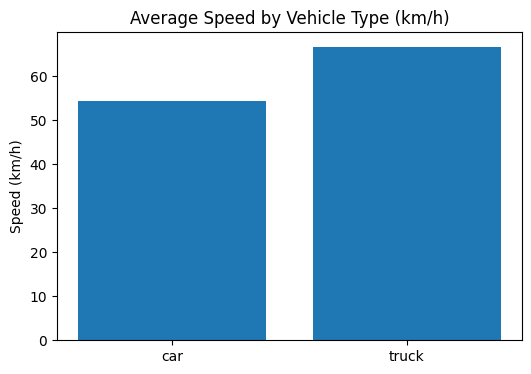

In [8]:
avg_by_label = vehicle_summary.groupby("label")["avg_speed_kmh"].mean().reset_index()

plt.figure(figsize=(6, 4))
plt.bar(avg_by_label["label"], avg_by_label["avg_speed_kmh"])
plt.title("Average Speed by Vehicle Type (km/h)")
plt.ylabel("Speed (km/h)")
plt.show()

## 8. 💬 Ask your traffic data (LLM chatbot)
Powered by **Groq** (free, no credit card required). Get a free key at https://console.groq.com/keys

Uses a safe **text-to-pandas** pattern: the LLM writes a pandas expression from the question, we validate and run it ourselves, then the LLM phrases the real computed result in plain English -- so answers are backed by actual math, not guessed.

In [9]:
# The chatbot reads GROQ_API_KEY from a .env file automatically (see .env.example).
# Only uncomment the line below if you are NOT using a .env file:
# import os; os.environ["GROQ_API_KEY"] = "paste-your-groq-key-here"

from modules import chatbot

result = chatbot.ask("How many vehicles crossed the line in total?", vehicle_summary)
print(result["answer"])

A total of 113 vehicles crossed the line.


In [10]:
# Try your own question:
question = "What was the fastest vehicle's speed?"
result = chatbot.ask(question, vehicle_summary)
print(result["answer"])

The fastest vehicle recorded a speed of 178.2 km/h.


## 9. Save the CSV log and download the output video

In [11]:
vehicle_summary.to_csv("vehicle_summary.csv", index=False)
print("Saved vehicle_summary.csv")

# --- Colab only: uncomment to download files ---
# from google.colab import files
# files.download(OUTPUT_VIDEO)
# files.download("vehicle_summary.csv")

Saved vehicle_summary.csv


## Next steps
- Try `python process_video.py --input ... --output ... --real_distance_m ... --pixel_distance ...` from the command line for a no-notebook batch run.
- Run `streamlit run app.py` for a live interactive dashboard version (webcam or upload, with the same chatbot built in).
- See `README.md` for calibration tips, directional counting, and possible extensions (homography correction, ByteTrack, edge deployment).